## Logistic Regression

Đây là mô hình thuộc nhóm phân loại

### Hàm kích hoạt (Activation function)

Đối với mô hình PLA, giá trị dự đoán của mô hình với dữ liệu đầu vào là $\mathbf{x} $ sẽ là:
$$
\hat{y} = \operatorname{sign}(\mathbf{\bar{x}}\mathbf{w})
$$
Nếu đặt $f(s) = \operatorname{sign}(s)$, thì giá trị dự đoán của mô hình sẽ là
$$
\hat{y} = f(\mathbf{\bar{x}}\mathbf{w})
$$
Ta có thể gọi $f(s)$ là một hàm kích hoạt.

### Một số activation function thường gặp
**Hàm sigmoid**
$$
\sigma (s) = \frac{1}{1 + e^{-s}}
$$
$$
\sigma '(s) = \sigma (s)(1 - \sigma (s))
$$
**Hàm tanh**
$$
\tanh(s) = \frac{e^s - e^{-s}}{e^s + e^{-s}} = 2\sigma (2s) - 1 
$$

### Hàm mất mát

Đối với bài toán phân loại nhị phân. Với điểm dữ liệu $\mathbf{x}_i$ 
Xác suất $\mathbf{x}_i$ thuộc lớp có nhãn $y_i = 1$ 
$$
P(y_i = 1|\mathbf{x}_i, w) = f(\mathbf{\bar{x}}_i\mathbf{w})
$$

Và xác suất $\mathbf{x}_i$ thuộc lớp có nhãn $y_i = 0$
$$
P(y_i = 0 |\mathbf{x}_i, \mathbf{w}) = 1 - P(y_i = 1|\mathbf{x}_i, \mathbf{w})
$$  
Đặt $\hat{y}_i = f(\mathbf{\bar{x}}_i\mathbf{w})$, ta kỳ vọng rằng mô hình sẽ đưa ra $\hat{y}_i \to 1$ khi $\mathbf{x}_i$ có nhãn $y_i = 1$. Và $\hat{y}_i \to 0$ khi $\mathbf{x}_i$ có nhãn $y_i = 0$. 

Ta có thể biểu diễn điều trên thông qua công thức
$$
P(y_i|\mathbf{x}_i, \mathbf{w}) = \hat{y}_i^{y_i}(1 - \hat{y}_i)^{1 - y_i} \to 1
$$

Phân tích công thức trên,

**Khi $y_i = 0$, ta có:**
$$
P(y_i = 0|\mathbf{x}_i, \mathbf{w}) = \hat{y}_i^{0}(1 - \hat{y}_i)^{1} = 1 - \hat{y}_i
$$
- Như vậy, $\hat{y}_i \to 0$ thì $P(y_i|\mathbf{x}_i, \mathbf{w}) \to 1$

**Khi $y_i = 1$, ta có:**
$$
P(y_i = 1|\mathbf{x}_i, \mathbf{w}) = \hat{y}_i^{1}(1 - \hat{y}_i)^{0} = \hat{y}_i
$$
- Như vậy, $\hat{y}_i \to 1$ thì $P(y_i|\mathbf{x}_i, \mathbf{w}) \to 1$

Xét toàn một trên tập dữ liệu 
$$
\mathbf{X} 
= 
\begin{bmatrix} 
\mathbf{x}_1 \\
... \\ 
\mathbf{x}_n
\end{bmatrix}
$$

Ta kỳ vọng rằng:
$$
P(\mathbf{y} | \mathbf{X}, \mathbf{w}) \to 1
$$
Giả sử các điểm dữ liệu độc lập với nhau, khi đó
$$
P(\mathbf{y} | \mathbf{X}, \mathbf{w}) 
= P(y_i | \mathbf{x}_1...\mathbf{x}_n, \mathbf{w}) 
= \prod _{i = 1}^N P(y_i | \mathbf{x}_i, \mathbf{w}) \to 1
$$
Như vậy bài toán tối ưu cần phải giải:
$$
\mathbf{w} 
= \argmax_\mathbf{w} \prod _{i = 1}^N P(y_i | \mathbf{x}_i, \mathbf{w}) \\
= -\argmin_\mathbf{w} \sum _{i = 1}^N \log(P(y_i | \mathbf{x}_i, \mathbf{w})) \\
= -\argmin_\mathbf{w} \sum _{i = 1}^N \log(\hat{y}_i^{y_i}(1 - \hat{y}_i)^{1 - y_i}) \\
= -\argmin_\mathbf{w} \sum _{i = 1}^N (y_i\log(\hat{y}_i) + (1-y_i)\log(1 - \hat{y}_i)) \\
= -\argmin_\mathbf{w} (\mathbf{Y}^T\log(\mathbf{\hat{Y}}) + (1-\mathbf{Y})^T\log(1 - \mathbf{\hat{Y}}))
$$

Sử dụng SGD để giải quyết bài toán tối ưu trên
Xét hàm mất mát
$$
\mathcal{L}(\hat{y}_i, y_i) = -(y_i\log(\hat{y}_i) + (1-y_i)\log(1 - \hat{y}_i))
$$
Đặt $z_i = \mathbf{\bar{x}}_i\mathbf{w}$, chọn $f(s) = \sigma(s)$. Tính đạo hàm riêng theo $\mathbf{w}$, sử dụng quy tắc chuỗi
$$
\frac{\partial \mathcal{L}}{\partial \mathbf{w}} 
= \frac{\partial \mathcal{L}}{\partial \hat{y}_i} \cdot
  \frac{\partial \hat{y}_i}{\partial z_i} \cdot
  \frac{\partial z_i}{\partial \mathbf{w}}
= \left(\frac{1 - y_i}{1 - \hat{y}_i} - \frac{y_i}{\hat{y}_i}\right) \cdot
  \hat{y}_i(1 - \hat{y}_i) \cdot
  \mathbf{\bar{x}}_i^T
= (\hat{y}_i - y_i)\mathbf{\bar{x}}_i^T
$$

Quy tắc cập nhật
$$
\mathbf{w} = \mathbf{w} - \eta \frac{\partial \mathcal{L}}{\partial \mathbf{w}}
$$

In [178]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(s):
    return 1 / (1 + np.exp(-s))

class LRModel:
    def __init__(self):
        self.w = None
        self.actfunc = sigmoid
    
    def fit(self, X, y, eta = 0.05, epsilon = 0.002):
        self.w = np.random.rand(X.shape[1] + 1).reshape(-1, 1)
        w = [self.w]
        for it in range(1000):    
            idx  = np.random.randint(0, X.shape[0])
            xi   = X[idx : idx+1 :]
            yi   = y[idx : idx+1 :]
            yhat = self.predict(xi)
            xbar = self.bar(xi)
            grad = (yhat - yi) * xbar.T
            self.w = self.w - eta * grad
            # if np.linalg.norm(self.w - w[-1]) <= epsilon:
            #     break
            w.append(self.w)
        return it
        
    def bar(self, X):
        one = np.ones((X.shape[0], 1))
        return np.concatenate((one, X), axis = 1)

    def predict(self, X):
        Xbar = self.bar(X)
        Z    = Xbar @ self.w
        return self.actfunc(Z)

In [179]:
def draw(X, y):
    plt.figure(figsize=[6, 6])
    plt.axis('equal')
    plt.scatter(X, y, color='blue', marker='o')
    plt.show()

In [180]:
X = np.array([[0.50, 0.75, 1.00, 1.25, 1.50, 1.75, 1.75, 2.00, 2.25, 2.50, 2.75, 3.00, 3.25, 3.50, 4.00, 4.25, 4.50, 4.75, 5.00, 5.50]]).T
y = np.array([[   0,    0,    0,    0,    0,    0,    1,    0,    1,    0,    1,    0,    1,    0,    1,    1,    1,    1,    1,    1]]).T

In [181]:
model = LRModel()
print(model.fit(X, y))
X_test = np.array([[2.5, 8.2]]).T
model.predict(X_test)

999


array([[0.61937296],
       [0.9994272 ]])

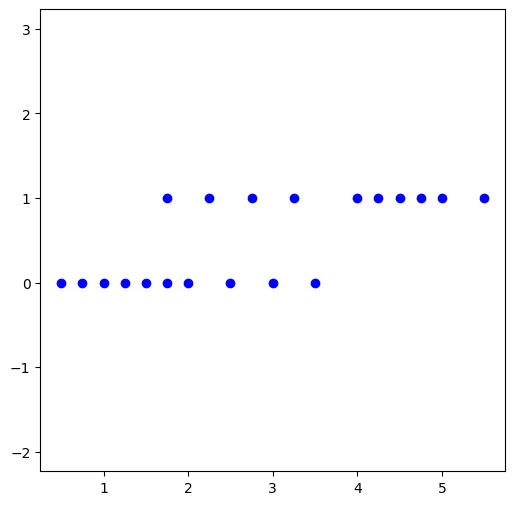

In [182]:
draw(X, y)